In [ ]:
!pip -q install einops tqdm

## Task 0

Device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 19.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 516kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.79MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.84MB/s]


x dtype: torch.float32
x shape: (128, 1, 28, 28)
x min/max: -1.0 1.0
y dtype: torch.int64 shape: (128,)
x on device: cuda:0
Saved: out/real_grid_MNIST.png


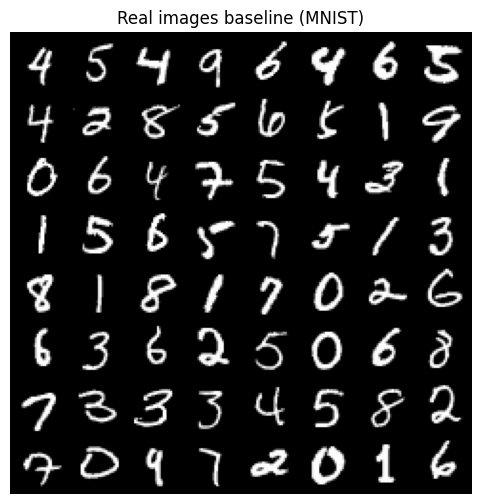

In [ ]:
import os
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt

# -------------------
# 1) Choose dataset
# -------------------
DATASET = "MNIST"          # change to "FashionMNIST" if you want
BATCH_SIZE = 128
NUM_WORKERS = 2
OUTDIR = "out"
os.makedirs(OUTDIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# -------------------
# 2) Transform to a known range
#    Recommended: [-1, 1]
# -------------------
transform = transforms.Compose([
    transforms.ToTensor(),                 # converts PIL -> float tensor in [0,1], shape (1,28,28)
    transforms.Lambda(lambda x: x * 2 - 1)  # map [0,1] -> [-1,1]
])

# -------------------
# 3) Dataset + DataLoader
# -------------------
ds_cls = datasets.MNIST if DATASET == "MNIST" else datasets.FashionMNIST
train_ds = ds_cls(root="./data", train=True, download=True, transform=transform)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
)

# Sanity check one batch
x, y = next(iter(train_loader))

print("x dtype:", x.dtype)              # should be torch.float32
print("x shape:", tuple(x.shape))       # should be (B, 1, 28, 28)
print("x min/max:", float(x.min()), float(x.max()))  # should be around [-1, 1]
print("y dtype:", y.dtype, "shape:", tuple(y.shape))

# Optional: confirm GPU transfer works
x_gpu = x.to(device, non_blocking=True)
print("x on device:", x_gpu.device)

# -------------------
# 4) Save a grid of real images (baseline reference)
#    Convert back to [0,1] ONLY for visualization/saving.
# -------------------
grid = make_grid((x[:64] + 1) / 2, nrow=8)  # 64 images in an 8x8 grid
path = os.path.join(OUTDIR, f"real_grid_{DATASET}.png")
save_image(grid, path)
print("Saved:", path)

# Show the saved grid inline
plt.figure(figsize=(6,6))
plt.imshow(grid.permute(1,2,0).cpu().numpy(), cmap="gray")
plt.axis("off")
plt.title(f"Real images baseline ({DATASET})")
plt.show()

## Task 1 — Schedules + forward noising

In [ ]:
import torch
import math
import matplotlib.pyplot as plt

def make_beta_schedule(L, schedule_type="linear", beta_min=1e-4, beta_max=0.02, device="cuda"): ##Schedules
    """
    Returns betas: tensor of shape [L]
    schedule_type: "linear" (required baseline), optionally "cosine"
    """
    if schedule_type == "linear":
        betas = torch.linspace(beta_min, beta_max, L, device=device)
    elif schedule_type == "cosine":
        # optional alternative; linear is fine for assignment baseline
        s = 0.008
        t = torch.linspace(0, L, L+1, device=device) / L
        f = torch.cos((t + s) / (1 + s) * math.pi / 2) ** 2
        alpha_bar = f / f[0]
        betas = 1 - (alpha_bar[1:] / alpha_bar[:-1])
        betas = betas.clamp(1e-8, 0.999)
    else:
        raise ValueError(f"Unknown schedule_type: {schedule_type}")
    return betas

In [ ]:
class DiffusionForward:
    """
    Forward-process utilities: schedule + q_sample (closed-form marginal).
    Uses 0-based t in {0,...,L-1}.
    """
    def __init__(self, L=1000, schedule_type="linear", beta_min=1e-4, beta_max=0.02, device="cuda"):
        self.L = L
        self.device = device

        self.betas = make_beta_schedule(L, schedule_type, beta_min, beta_max, device=device)  # [L]
        self.alphas = 1.0 - self.betas                                                      # α_t
        self.alpha_bar = torch.cumprod(self.alphas, dim=0)                                   # ᾱ_t

        self.sqrt_alpha_bar = torch.sqrt(self.alpha_bar)                                     # √ᾱ_t
        self.sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - self.alpha_bar)                     # √(1-ᾱ_t)
        self.inv_sqrt_alpha = 1.0 / torch.sqrt(self.alphas)                                  # 1/√α_t

    def sample_timesteps(self, batch_size):
        """
        Samples t ~ Uniform{0,...,L-1}  (equivalent to i ~ Uniform{1,...,L} in 1-based form)
        """
        return torch.randint(low=0, high=self.L, size=(batch_size,), device=self.device, dtype=torch.long)

    def q_sample(self, x0, t, eps=None):
        """
        Implements eq (2):
        x_t = √ᾱ_t * x0 + √(1-ᾱ_t) * eps,   eps ~ N(0, I)
        x0: [B,C,H,W]
        t:  [B] (0-based)
        """
        if eps is None:
            eps = torch.randn_like(x0)

        # gather per-sample scalars and reshape for broadcasting
        s1 = self.sqrt_alpha_bar[t].view(-1, 1, 1, 1)
        s2 = self.sqrt_one_minus_alpha_bar[t].view(-1, 1, 1, 1)
        return s1 * x0 + s2 * eps

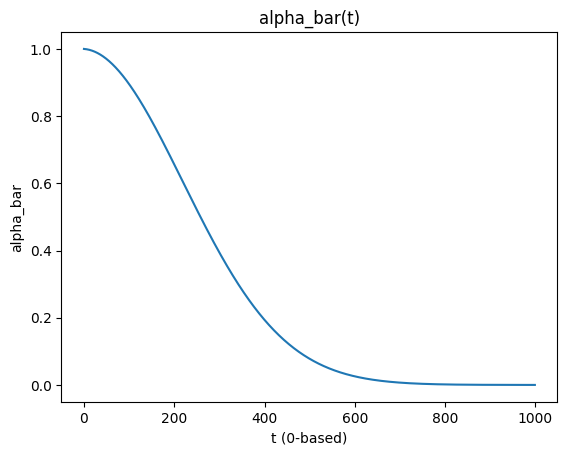

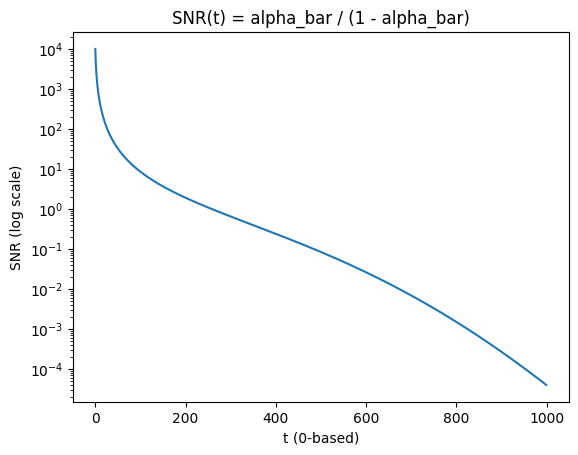

In [ ]:
# create schedule
device = "cuda" if torch.cuda.is_available() else "cpu"
fwd = DiffusionForward(L=1000, schedule_type="linear", beta_min=1e-4, beta_max=0.02, device=device)

alpha_bar = fwd.alpha_bar.detach().cpu()
snr = (alpha_bar / (1 - alpha_bar)).clamp(min=1e-12)

plt.figure()
plt.plot(alpha_bar.numpy())
plt.title("alpha_bar(t)")
plt.xlabel("t (0-based)")
plt.ylabel("alpha_bar")
plt.show()

plt.figure()
plt.plot(snr.numpy())
plt.yscale("log")
plt.title("SNR(t) = alpha_bar / (1 - alpha_bar)")
plt.xlabel("t (0-based)")
plt.ylabel("SNR (log scale)")
plt.show()

In [ ]:
# Grab one fixed image x0 from your existing DataLoader (MNIST/FashionMNIST)
# Assumes your images are already scaled to [-1, 1]
x0, _ = next(iter(train_loader))
x0 = x0[:1].to(device)  # take ONE fixed image, shape [1,1,28,28]

t0 = 500  # pick a timestep (0-based)
N = 2048  # number of repeated samples for empirical check

t = torch.full((N,), t0, device=device, dtype=torch.long)
x0_rep = x0.repeat(N, 1, 1, 1)  # [N,1,28,28]
eps = torch.randn_like(x0_rep)

x_t_samples = fwd.q_sample(x0_rep, t, eps=eps)  # [N,1,28,28]

emp_mean = x_t_samples.mean(dim=0)  # [1,28,28]
emp_var  = x_t_samples.var(dim=0, unbiased=False)  # [1,28,28]

the_mean = fwd.sqrt_alpha_bar[t0] * x0[0]  # [1,28,28]
the_var_scalar = (1.0 - fwd.alpha_bar[t0]).item()  # scalar

# report errors
mean_abs_err = (emp_mean - the_mean).abs().mean().item()
var_abs_err  = (emp_var - the_var_scalar).abs().mean().item()

print("t =", t0)
print("Theoretical var scalar (1 - alpha_bar_t):", the_var_scalar)
print("Mean |emp - theory| (avg abs):", mean_abs_err)
print("Var  |emp - theory| (avg abs):", var_abs_err)

t = 500
Theoretical var scalar (1 - alpha_bar_t): 0.9222033023834229
Mean |emp - theory| (avg abs): 0.01743808202445507
Var  |emp - theory| (avg abs): 0.02351289801299572


## Task 2

In [ ]:
class DiffusionReverse(DiffusionForward):
    def __init__(self, L=1000, schedule_type="linear", beta_min=1e-4, beta_max=0.02, device="cuda"):
        super().__init__(L, schedule_type, beta_min, beta_max, device)

        # alpha_bar_{t-1} with alpha_bar_prev[0] = 1
        self.alpha_bar_prev = torch.cat(
            [torch.tensor([1.0], device=self.device), self.alpha_bar[:-1]],
            dim=0
        )

        # beta_tilde_t (posterior variance)
        self.beta_tilde = self.betas * (1.0 - self.alpha_bar_prev) / (1.0 - self.alpha_bar)
        self.beta_tilde = torch.clamp(self.beta_tilde, min=1e-20)  # safety

        # coefficients for posterior mean: mu_tilde = c1*x0 + c2*xt
        self.posterior_mean_coef1 = self.betas * torch.sqrt(self.alpha_bar_prev) / (1.0 - self.alpha_bar)
        self.posterior_mean_coef2 = (1.0 - self.alpha_bar_prev) * torch.sqrt(self.alphas) / (1.0 - self.alpha_bar)

    def q_posterior_mean_var(self, x0, x_t, t):
        """
        Returns:
          mu_tilde_t(x_t, x0) and beta_tilde_t
        x0, x_t: [B,C,H,W]
        t: [B] 0-based
        """
        c1 = self.posterior_mean_coef1[t].view(-1,1,1,1)
        c2 = self.posterior_mean_coef2[t].view(-1,1,1,1)
        mu = c1 * x0 + c2 * x_t
        var = self.beta_tilde[t].view(-1,1,1,1)
        return mu, var

    def predict_x0_from_eps(self, x_t, t, eps_hat):
        """
        x0_hat = 1/sqrt(alpha_bar_t) * (x_t - sqrt(1-alpha_bar_t)*eps_hat)
        """
        s1 = (1.0 / self.sqrt_alpha_bar[t]).view(-1,1,1,1)
        s2 = self.sqrt_one_minus_alpha_bar[t].view(-1,1,1,1)
        return s1 * (x_t - s2 * eps_hat)

    def p_mean_from_eps(self, x_t, t, eps_hat):
        """
        DDPM reverse mean (eq 8):
        mu = 1/sqrt(alpha_t) * (x_t - beta_t/sqrt(1-alpha_bar_t) * eps_hat)
        """
        beta_t = self.betas[t].view(-1,1,1,1)
        inv_sqrt_alpha_t = self.inv_sqrt_alpha[t].view(-1,1,1,1)
        denom = self.sqrt_one_minus_alpha_bar[t].view(-1,1,1,1)
        mu = inv_sqrt_alpha_t * (x_t - (beta_t / denom) * eps_hat)
        return mu

    @torch.no_grad()
    def p_sample_step(self, x_t, t, eps_hat):
        """
        Returns x_{t-1}:
          if t > 0: mu + sqrt(beta_tilde_t)*z
          if t = 0: mu
        """
        mu = self.p_mean_from_eps(x_t, t, eps_hat)
        var = self.beta_tilde[t].view(-1,1,1,1)

        # for t==0, no noise
        noise = torch.randn_like(x_t)
        mask = (t > 0).float().view(-1,1,1,1)
        return mu + mask * torch.sqrt(var) * noise

In [ ]:
rev = DiffusionReverse(L=1000, schedule_type="linear", beta_min=1e-4, beta_max=0.02, device=device)

In [ ]:
bt = rev.beta_tilde.detach().cpu()
b  = rev.betas.detach().cpu()

print("min beta_tilde:", bt.min().item())
print("all beta_tilde > 0:", bool((bt > 0).all()))

# usually for t>=1 (i>=2) beta_tilde < beta
ratio_ok = (bt[1:] < b[1:]).float().mean().item()
print("fraction of timesteps (t>=1) where beta_tilde < beta:", ratio_ok)

min beta_tilde: 9.999999682655225e-21
all beta_tilde > 0: True
fraction of timesteps (t>=1) where beta_tilde < beta: 1.0


In [ ]:
# pick a batch
x0, _ = next(iter(train_loader))
x0 = x0.to(device)

B = x0.shape[0]
t_int = 500
t = torch.full((B,), t_int, device=device, dtype=torch.long)

# create x_t from true eps Then we inject noise using the schedule
eps = torch.randn_like(x0)
x_t = rev.q_sample(x0, t, eps=eps)

# compute true posterior mean/var using x0 (teacher)
mu_tilde, var_tilde = rev.q_posterior_mean_var(x0, x_t, t)

# sample x_{t-1} from the TRUE posterior
z = torch.randn_like(x0)
x_tm1 = mu_tilde + torch.sqrt(var_tilde) * z

print("x_t   min/max:", float(x_t.min()), float(x_t.max()))
print("x_tm1 min/max:", float(x_tm1.min()), float(x_tm1.max()))

# quick check: x_{t-1} should be slightly less noisy than x_t
# (not a strict numeric guarantee per pixel, but visually it should look a bit cleaner)

x_t   min/max: -4.613874912261963 4.033318996429443
x_tm1 min/max: -4.416379928588867 3.99469256401062


x0             min/max: -1.0000 1.0000 | mean/std: -0.7210 0.6214
x_t            min/max: -3.4208 2.8239 | mean/std: -0.1051 0.9522
x0_hat         min/max: -1.0000 1.0000 | mean/std: -0.7210 0.6214
x_tm1_teacher  min/max: -3.2900 2.8056 | mean/std: -0.1075 0.9475
x_tm1_from_eps min/max: -3.2880 2.7890 | mean/std: -0.1052 0.9516


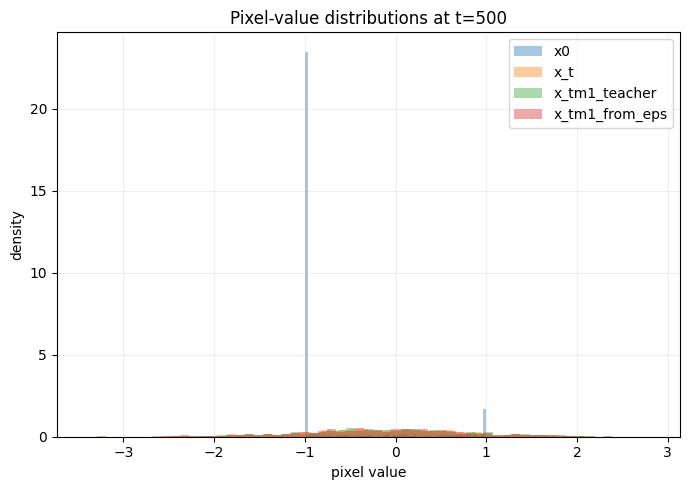

Saved: out/value_hist_t500.png


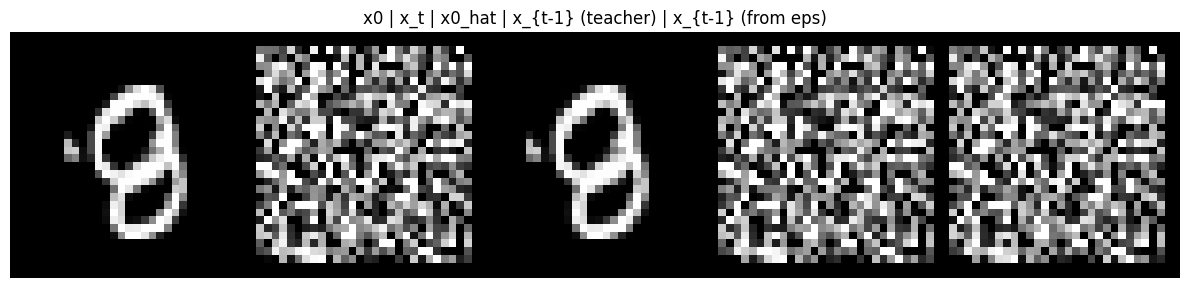

Saved: out/compare_t500.png


In [ ]:
import os
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid, save_image

os.makedirs("out", exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"

# 1) pick ONE fixed image x0
x0, _ = next(iter(train_loader))
x0 = x0[:1].to(device)  # [1,1,28,28]

# 2) choose timestep
t_int = 500
t = torch.tensor([t_int], device=device, dtype=torch.long)

# 3) forward: create x_t from true eps
eps = torch.randn_like(x0)
x_t = rev.q_sample(x0, t, eps=eps)

# 4) true posterior sample x_{t-1} using x0 (teacher)
mu_tilde, var_tilde = rev.q_posterior_mean_var(x0, x_t, t)
x_tm1_teacher = mu_tilde + torch.sqrt(var_tilde) * torch.randn_like(x0)

# 5) reverse using eps_hat = true eps (sanity)
x0_hat = rev.predict_x0_from_eps(x_t, t, eps_hat=eps)
x_tm1_from_eps = rev.p_sample_step(x_t, t, eps_hat=eps)

# ---- print min/max/mean/std ----
def stats(name, x):
    print(f"{name:14s} min/max: {float(x.min()):.4f} {float(x.max()):.4f} | mean/std: {float(x.mean()):.4f} {float(x.std(unbiased=False)):.4f}")

stats("x0", x0)
stats("x_t", x_t)
stats("x0_hat", x0_hat)
stats("x_tm1_teacher", x_tm1_teacher)
stats("x_tm1_from_eps", x_tm1_from_eps)

# ---- histogram plot (pixel values) ----
vals = {
    "x0": x0.detach().cpu().flatten(),
    "x_t": x_t.detach().cpu().flatten(),
    "x_tm1_teacher": x_tm1_teacher.detach().cpu().flatten(),
    "x_tm1_from_eps": x_tm1_from_eps.detach().cpu().flatten(),
}

plt.figure(figsize=(7,5))
for k, v in vals.items():
    plt.hist(v.numpy(), bins=60, alpha=0.4, density=True, label=k)
plt.title(f"Pixel-value distributions at t={t_int}")
plt.xlabel("pixel value")
plt.ylabel("density")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(f"out/value_hist_t{t_int}.png", dpi=150)
plt.show()

print(f"Saved: out/value_hist_t{t_int}.png")

# ---- image grid (side-by-side) ----
# for visualization only: clamp to [-1,1] then map to [0,1]
def vis(x):
    return (x.clamp(-1,1) + 1) / 2

grid = make_grid(
    torch.cat([vis(x0), vis(x_t), vis(x0_hat), vis(x_tm1_teacher), vis(x_tm1_from_eps)], dim=0),
    nrow=5
)

save_image(grid, f"out/compare_t{t_int}.png")
plt.figure(figsize=(12,3))
plt.imshow(grid.permute(1,2,0).cpu().numpy(), cmap="gray")
plt.axis("off")
plt.title("x0 | x_t | x0_hat | x_{t-1} (teacher) | x_{t-1} (from eps)")
plt.tight_layout()
plt.show()

print(f"Saved: out/compare_t{t_int}.png")

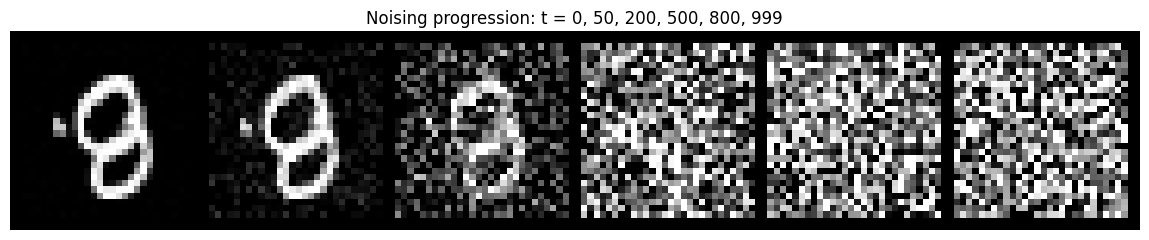

Saved: out/noise_progression.png


In [ ]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid, save_image

t_list = [0, 50, 200, 500, 800, 999]
rows = []

for ti in t_list:
    tt = torch.tensor([ti], device=device, dtype=torch.long)
    eps_i = torch.randn_like(x0)
    x_ti = rev.q_sample(x0, tt, eps=eps_i)
    rows.append((x_ti.clamp(-1,1) + 1) / 2)

grid2 = make_grid(torch.cat(rows, dim=0), nrow=len(t_list))
save_image(grid2, "out/noise_progression.png")

plt.figure(figsize=(14,2.5))
plt.imshow(grid2.permute(1,2,0).cpu().numpy(), cmap="gray")
plt.axis("off")
plt.title("Noising progression: t = 0, 50, 200, 500, 800, 999")
plt.tight_layout()
plt.show()

print("Saved: out/noise_progression.png")

## Task 3

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

def sinusoidal_timestep_embedding(t, dim):
    """
    t: [B] integer timesteps
    returns: [B, dim]
    """
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(0, half, device=t.device) / half)
    args = t[:, None].float() * freqs[None, :]
    emb = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    if dim % 2 == 1:
        emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=-1)
    return emb

In [ ]:
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, t_emb_dim, groups=8):
        super().__init__()
        self.norm1 = nn.GroupNorm(groups, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)

        self.norm2 = nn.GroupNorm(groups, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        # inject time embedding here
        self.t_proj = nn.Linear(t_emb_dim, out_ch)

        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.t_proj(t_emb).view(t_emb.shape[0], -1, 1, 1)  # <-- timestep injected
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)

In [ ]:
class Downsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 3, stride=2, padding=1)
    def forward(self, x):
        return self.conv(x)

class Upsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 3, padding=1)
    def forward(self, x):
        x = F.interpolate(x, scale_factor=2.0, mode="nearest")
        return self.conv(x)

class EpsUNet(nn.Module):
    """
    epsilon_theta(x_t, t): predicts noise with same shape as input
    """
    def __init__(self, in_ch=1, base_ch=32, ch_mult=(1,2,4), t_emb_dim=128):
        super().__init__()
        self.t_emb_dim = t_emb_dim

        # time embedding -> MLP
        self.time_mlp = nn.Sequential(
            nn.Linear(t_emb_dim, t_emb_dim*4),
            nn.SiLU(),
            nn.Linear(t_emb_dim*4, t_emb_dim),
        )

        chs = [base_ch*m for m in ch_mult]  # [32, 64, 128]

        self.in_conv = nn.Conv2d(in_ch, chs[0], 3, padding=1)

        # down path
        self.d1 = ResBlock(chs[0], chs[0], t_emb_dim)
        self.d2 = ResBlock(chs[0], chs[1], t_emb_dim)
        self.ds1 = Downsample(chs[1])

        self.d3 = ResBlock(chs[1], chs[1], t_emb_dim)
        self.d4 = ResBlock(chs[1], chs[2], t_emb_dim)
        self.ds2 = Downsample(chs[2])

        # bottleneck
        self.mid1 = ResBlock(chs[2], chs[2], t_emb_dim)
        self.mid2 = ResBlock(chs[2], chs[2], t_emb_dim)

        # up path
        self.us2 = Upsample(chs[2])
        self.u4 = ResBlock(chs[2] + chs[2], chs[1], t_emb_dim)
        self.u3 = ResBlock(chs[1], chs[1], t_emb_dim)

        self.us1 = Upsample(chs[1])
        self.u2 = ResBlock(chs[1] + chs[1], chs[0], t_emb_dim)
        self.u1 = ResBlock(chs[0], chs[0], t_emb_dim)

        self.out_norm = nn.GroupNorm(8, chs[0])
        self.out_conv = nn.Conv2d(chs[0], in_ch, 3, padding=1)

    def forward(self, x_t, t):
        # t embedding
        t_emb = sinusoidal_timestep_embedding(t, self.t_emb_dim)
        t_emb = self.time_mlp(t_emb)

        # down
        x = self.in_conv(x_t)
        s1 = self.d1(x, t_emb)
        s2 = self.d2(s1, t_emb)
        x = self.ds1(s2)

        s3 = self.d3(x, t_emb)
        s4 = self.d4(s3, t_emb)
        x = self.ds2(s4)

        # mid
        x = self.mid1(x, t_emb)
        x = self.mid2(x, t_emb)

        # up
        x = self.us2(x)
        x = torch.cat([x, s4], dim=1)
        x = self.u4(x, t_emb)
        x = self.u3(x, t_emb)

        x = self.us1(x)
        x = torch.cat([x, s2], dim=1)
        x = self.u2(x, t_emb)
        x = self.u1(x, t_emb)

        # output noise prediction
        eps_hat = self.out_conv(F.silu(self.out_norm(x)))
        return eps_hat

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
net = EpsUNet(in_ch=1, base_ch=32).to(device)

x = torch.randn(8, 1, 28, 28, device=device)          # fake x_t
t = torch.randint(0, 1000, (8,), device=device)       # timesteps
eps_hat = net(x, t)

print("x shape:", x.shape)
print("eps_hat shape:", eps_hat.shape)

x shape: torch.Size([8, 1, 28, 28])
eps_hat shape: torch.Size([8, 1, 28, 28])


In [ ]:
x = torch.randn(1, 1, 28, 28, device=device)
t1 = torch.tensor([10], device=device)
t2 = torch.tensor([900], device=device)

e1 = net(x, t1)
e2 = net(x, t2)

print("mean abs diff:", (e1 - e2).abs().mean().item())

mean abs diff: 0.10384725034236908


## Task 4

/tmp/ipykernel_840/2870050797.py:24: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
  0%|          | 0/20000 [00:00<?, ?it/s]/tmp/ipykernel_840/2870050797.py:77: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
  1%|          | 203/20000 [00:14<21:10, 15.58it/s]

step 200 | loss(avg)=0.1134 | grad_norm=41391.706


  2%|▏         | 403/20000 [00:27<21:38, 15.10it/s]

step 400 | loss(avg)=0.0441 | grad_norm=28474.673


  3%|▎         | 601/20000 [00:41<30:52, 10.47it/s]

...

step 19800 | loss(avg)=0.0216 | grad_norm=141678.939


100%|█████████▉| 19998/20000 [26:21<00:00, 12.97it/s]

step 20000 | loss(avg)=0.0216 | grad_norm=130892.589


100%|██████████| 20000/20000 [26:38<00:00, 12.51it/s]

Saved out/sample_step_20000.png


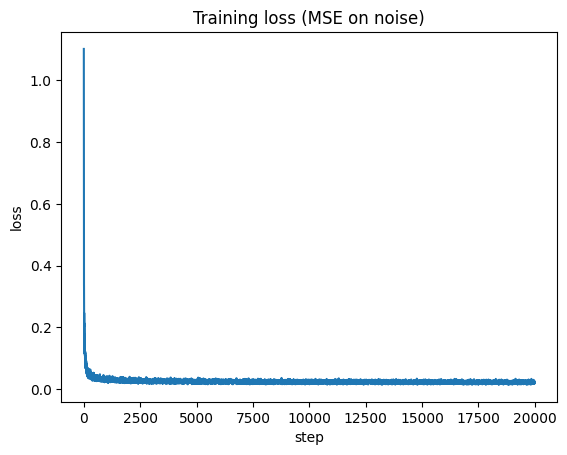

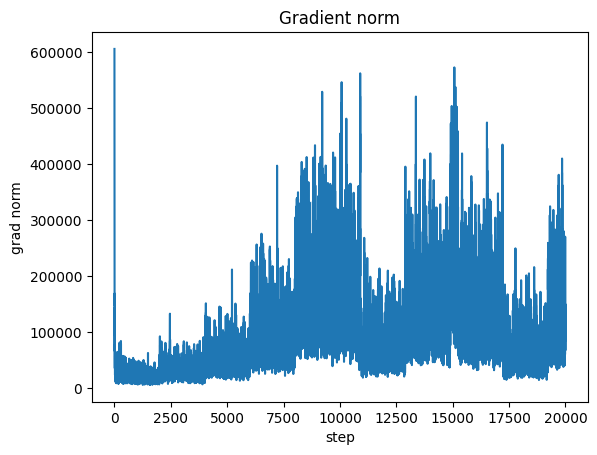

In [ ]:
import os
import math
import numpy as np
import torch
import torch.nn.functional as F
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
from tqdm import tqdm

os.makedirs("out", exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- IMPORTANT: make sure these exist ---
# rev: DiffusionReverse (has q_sample, sample_timesteps or you can use torch.randint)
# net: EpsUNet (predicts eps_hat)
# train_loader: DataLoader returning x0 in [-1,1]

net = net.to(device)
# If your rev already stores tensors on GPU, ok. Otherwise ensure schedule tensors are on device.

opt = torch.optim.AdamW(net.parameters(), lr=2e-4, weight_decay=0.0)

use_amp = True
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

L = rev.L  # number of diffusion steps
loss_hist = []
grad_norm_hist = []

LOG_EVERY = 200
SAMPLE_EVERY = 2000
TRAIN_STEPS = 20000  # increase toward 100k for better samples

def grad_norm(model):
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.detach().float().norm(2).item()**2
    return math.sqrt(total)

@torch.no_grad()
def sample_ddpm(net, rev, n=64, seed=0):
    net.eval()
    torch.manual_seed(seed)
    x = torch.randn(n, 1, 28, 28, device=device)  # start from pure noise

    for t_int in reversed(range(rev.L)):
        t = torch.full((n,), t_int, device=device, dtype=torch.long)
        eps_hat = net(x, t)
        x = rev.p_sample_step(x, t, eps_hat)  # uses beta_tilde, handles t==0
    return x

# training iterator
it = iter(train_loader)
net.train()

for step in tqdm(range(1, TRAIN_STEPS + 1)):
    try:
        x0, _ = next(it)
    except StopIteration:
        it = iter(train_loader)
        x0, _ = next(it)

    x0 = x0.to(device)

    # 2) sample timesteps uniformly
    t = torch.randint(0, L, (x0.shape[0],), device=device, dtype=torch.long)

    # 3) sample eps
    eps = torch.randn_like(x0)

    # 4) compute x_t via q_sample
    x_t = rev.q_sample(x0, t, eps=eps)

    # 5) predict eps_hat Noise
    opt.zero_grad(set_to_none=True)
    with torch.cuda.amp.autocast(enabled=use_amp):
        eps_hat = net(x_t, t)

        # 6) loss
        loss = F.mse_loss(eps_hat, eps)

    # 7) backprop + step
    scaler.scale(loss).backward()

    # optional: clip grad if you see explosions
    # torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)

    gnorm = grad_norm(net)
    scaler.step(opt)
    scaler.update()

    loss_hist.append(loss.item())
    grad_norm_hist.append(gnorm)

    # logging
    if step % LOG_EVERY == 0:
        print(f"step {step} | loss(avg)={np.mean(loss_hist[-LOG_EVERY:]):.4f} | grad_norm={np.mean(grad_norm_hist[-LOG_EVERY:]):.3f}")

    # periodic samples
    if step % SAMPLE_EVERY == 0:
        x_gen = sample_ddpm(net, rev, n=64, seed=0)
        grid = make_grid((x_gen.clamp(-1,1) + 1)/2, nrow=8)
        save_image(grid, f"out/sample_step_{step}.png")
        print(f"Saved out/sample_step_{step}.png")

# plot curves
plt.figure()
plt.plot(loss_hist)
plt.title("Training loss (MSE on noise)")
plt.xlabel("step")
plt.ylabel("loss")
plt.show()

plt.figure()
plt.plot(grad_norm_hist)
plt.title("Gradient norm")
plt.xlabel("step")
plt.ylabel("grad norm")
plt.show()

In [ ]:
from torch.utils.data import Subset, DataLoader

# Make a tiny dataset of 256 images
tiny_ds = Subset(train_loader.dataset, list(range(256)))
tiny_loader = DataLoader(tiny_ds, batch_size=128, shuffle=True, drop_last=True)

# Train a bit on tiny_loader (e.g., 5k–20k steps) and sample grids.
# If samples do NOT resemble the subset, something is wrong in fundamentals.

In [ ]:
@torch.no_grad()
def one_step_posterior_check(rev, train_loader, t_int=500, trials=200):
    x0, _ = next(iter(train_loader))
    x0 = x0[:1].to(device)  # one fixed image

    t = torch.tensor([t_int], device=device, dtype=torch.long)

    d_xt = []
    d_xtm1 = []

    for _ in range(trials):
        eps = torch.randn_like(x0)
        x_t = rev.q_sample(x0, t, eps=eps)

        mu_tilde, var_tilde = rev.q_posterior_mean_var(x0, x_t, t)
        x_tm1 = mu_tilde + torch.sqrt(var_tilde) * torch.randn_like(x0)

        d_xt.append(((x_t - x0)**2).mean().item())
        d_xtm1.append(((x_tm1 - x0)**2).mean().item())

    print("E[||x_t - x0||^2]   =", float(np.mean(d_xt)))
    print("E[||x_{t-1} - x0||^2] =", float(np.mean(d_xtm1)))
    print("Check passed:", np.mean(d_xtm1) < np.mean(d_xt))

one_step_posterior_check(rev, train_loader, t_int=500, trials=500)

E[||x_t - x0||^2]   = 1.3959576971530914
E[||x_{t-1} - x0||^2] = 1.393428904056549
Check passed: True


In [ ]:
## Task 5

## Task 5

Saved: out/final_samples.png
Saved: out/intermediate_t999.png
Saved: out/intermediate_t750.png
Saved: out/intermediate_t500.png
Saved: out/intermediate_t250.png
Saved: out/intermediate_t0.png


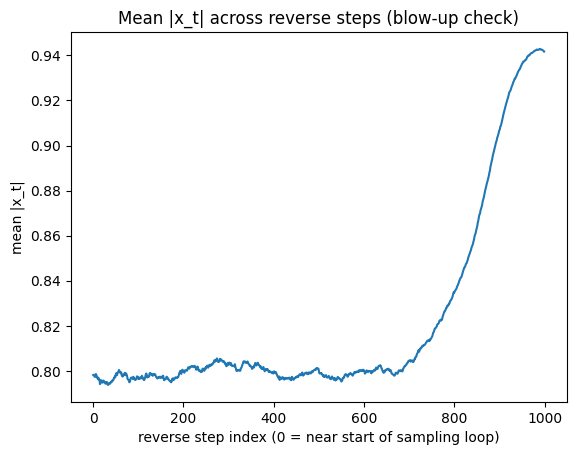

In [ ]:
import os
import torch
from torchvision.utils import make_grid, save_image

# Assumes you already have:
#  - net: your trained EpsUNet (eps_theta)
#  - rev: your DiffusionReverse object with:
#       rev.L
#       rev.p_sample_step(x_t, t, eps_hat)   # uses mu from eq (8) and variance beta_tilde, no noise at t=0
#  - device = "cuda" / "cpu"

@torch.no_grad()
def ddpm_ancestral_sample(
    net,
    rev,
    n=64,
    img_shape=(1, 28, 28),
    seed=0,
    save_intermediate=True,
    intermediate_ts=None,
    outdir="out"
):
    """
    Task 5: Full ancestral DDPM sampler.

    Starts from x_{L-1} ~ N(0, I) (0-based indexing),
    then for t = L-1, ..., 0:
      eps_hat = eps_theta(x_t, t)
      x_{t-1} ~ N(mu_theta(x_t,t), beta_tilde_t I) for t>0
      x_0 = mu_theta for t=0 (no added noise)

    Returns:
      x0: final samples in [-inf, inf] (typically clamp for viewing)
      intermediates: dict {t: tensor} of saved intermediate x_t (optional)
      norms: list of mean |x_t| over timesteps (for blow-up detection)
    """
    os.makedirs(outdir, exist_ok=True)
    net.eval()

    if intermediate_ts is None:
        # save a few default checkpoints: L-1, 3/4, 1/2, 1/4, 0
        L = rev.L
        intermediate_ts = sorted(set([
            L-1,
            int(3*L/4),
            int(L/2),
            int(L/4),
            0
        ]))

    torch.manual_seed(seed)

    # 1) Start from noise: x_{L-1} ~ N(0,I)
    x = torch.randn(n, *img_shape, device=rev.device)

    intermediates = {}
    norms = []

    # 2) Reverse chain: t = L-1 ... 0
    for t_int in reversed(range(rev.L)):
        t = torch.full((n,), t_int, device=rev.device, dtype=torch.long)

        # predict noise
        eps_hat = net(x, t)

        # one reverse step (adds noise if t>0, none if t==0)
        x = rev.p_sample_step(x, t, eps_hat)

        # diagnostics: track mean |x|
        norms.append(x.detach().abs().mean().item())

        # save intermediate x_t if requested
        if save_intermediate and (t_int in intermediate_ts):
            intermediates[t_int] = x.detach().cpu()

    return x, intermediates, norms


@torch.no_grad()
def save_sample_grid(x, path, nrow=8):
    """
    Save image grid. Assumes training data range [-1,1].
    Clamps for viewing and maps to [0,1].
    """
    x_vis = (x.clamp(-1, 1) + 1) / 2
    grid = make_grid(x_vis, nrow=nrow)
    save_image(grid, path)


# --------- Example usage after training ---------
# Generate final samples + intermediate checkpoints
x0, inter, norms = ddpm_ancestral_sample(
    net=net,
    rev=rev,
    n=64,
    img_shape=(1, 28, 28),
    seed=0,
    save_intermediate=True,
    outdir="out"
)

# Save final grid
save_sample_grid(x0, "out/final_samples.png", nrow=8)
print("Saved: out/final_samples.png")

# Save intermediate grids
for t_int, xt in sorted(inter.items(), reverse=True):
    save_sample_grid(xt, f"out/intermediate_t{t_int}.png", nrow=8)
    print(f"Saved: out/intermediate_t{t_int}.png")

# Plot norms to detect blow-ups
import matplotlib.pyplot as plt
plt.figure()
plt.plot(norms)
plt.title("Mean |x_t| across reverse steps (blow-up check)")
plt.xlabel("reverse step index (0 = near start of sampling loop)")
plt.ylabel("mean |x_t|")
plt.show()

## Task 6

Device: cuda

Running LINEAR schedule experiment...
GPU memory cleared


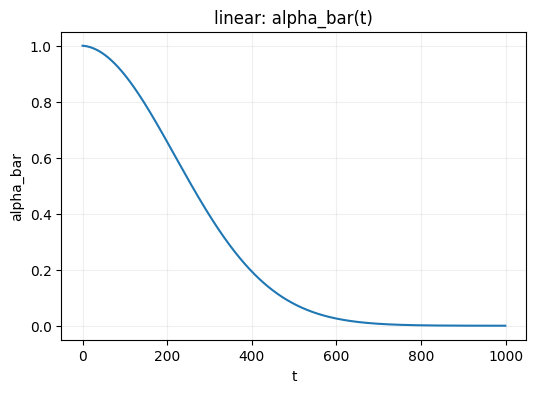

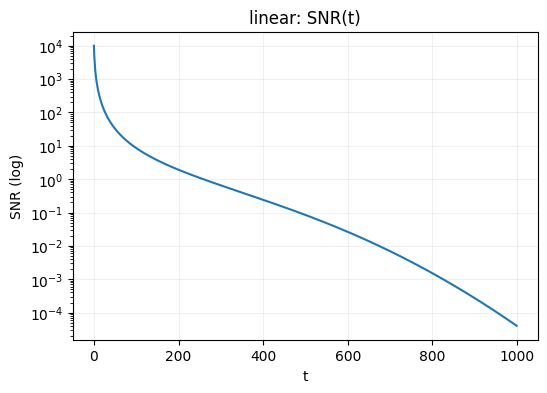

Training linear:  50%|█████     | 2503/5000 [02:13<26:33,  1.57it/s]

Saved: out/linear_sample_step_2500.png


Training linear: 100%|██████████| 5000/5000 [04:21<00:00, 19.09it/s]

Saved: out/linear_sample_step_5000.png


Saved: out/linear_final_ddpm.png
GPU memory cleared

Running COSINE schedule experiment...
GPU memory cleared


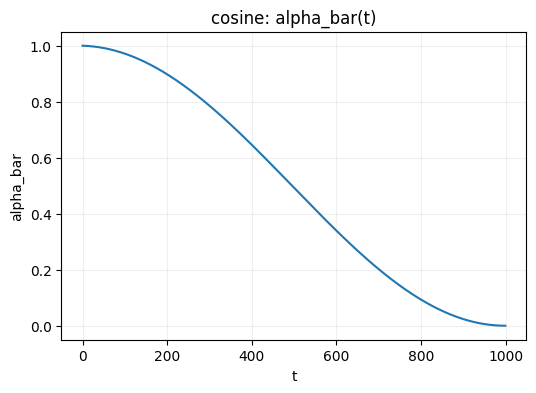

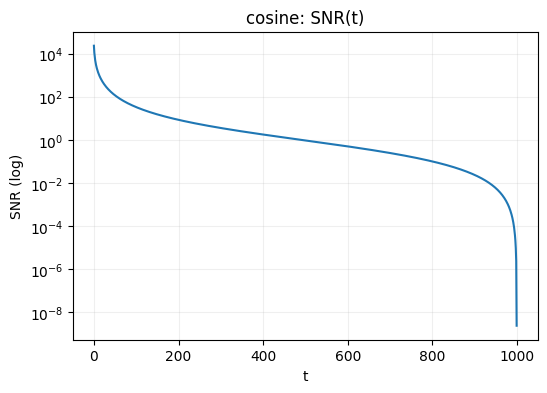

Training cosine:  50%|█████     | 2504/5000 [02:11<23:39,  1.76it/s]

Saved: out/cosine_sample_step_2500.png


Training cosine: 100%|██████████| 5000/5000 [04:24<00:00, 18.87it/s]

Saved: out/cosine_sample_step_5000.png


Saved: out/cosine_final_ddpm.png
GPU memory cleared


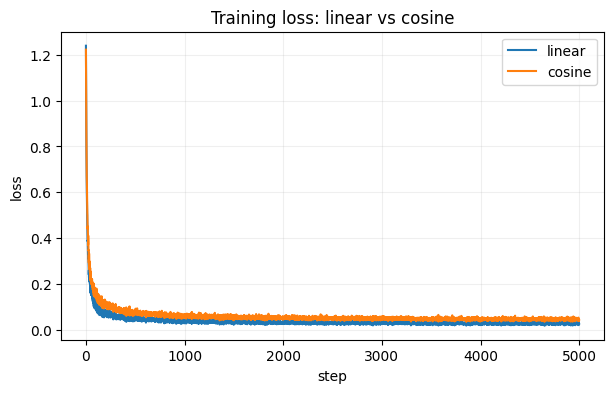

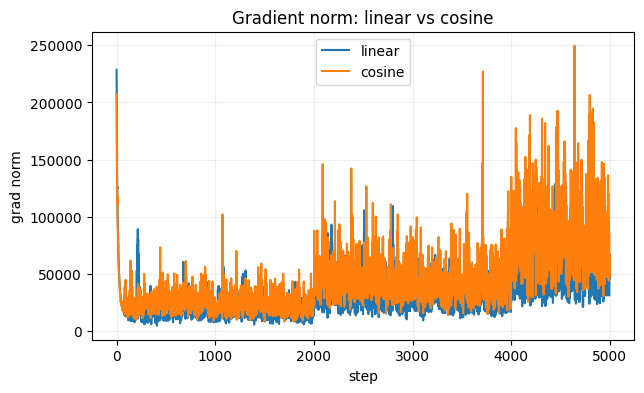

Better schedule by final loss: linear
GPU memory cleared
Saved: out/linear_ddpm_samples.png
Saved: out/linear_ddim_samples.png

Task 6 complete.
Saved files:
- out/linear_final_ddpm.png
- out/cosine_final_ddpm.png
- out/linear_ddpm_samples.png
- out/linear_ddim_samples.png
- out/linear_ckpt.pt
- out/cosine_ckpt.pt


In [ ]:
# =========================
# TASK 6 - FULL IN ONE CELL
# =========================

import gc
import math
import os
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.utils import make_grid, save_image
from tqdm import tqdm

# -----------------
# Basic setup
# -----------------
os.makedirs("out", exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# -----------------
# Memory helper
# -----------------
def free_gpu():
    gc.collect()
    torch.cuda.empty_cache()
    if torch.cuda.is_available():
        print("GPU memory cleared")

# -----------------
# Beta schedules
# -----------------
def make_beta_schedule(L, schedule_type="linear", beta_min=1e-4, beta_max=0.02, device="cuda"):
    if schedule_type == "linear":
        betas = torch.linspace(beta_min, beta_max, L, device=device)

    elif schedule_type == "cosine":
        s = 0.008
        t = torch.linspace(0, L, L + 1, device=device) / L
        f = torch.cos((t + s) / (1 + s) * math.pi / 2) ** 2
        alpha_bar = f / f[0]
        betas = 1.0 - (alpha_bar[1:] / alpha_bar[:-1])
        betas = betas.clamp(1e-8, 0.999)

    else:
        raise ValueError(f"Unknown schedule_type: {schedule_type}")

    return betas

# -----------------
# Diffusion class
# -----------------
class DiffusionReverse:
    def __init__(self, L=1000, schedule_type="linear", beta_min=1e-4, beta_max=0.02, device="cuda"):
        self.L = L
        self.device = device
        self.schedule_type = schedule_type

        self.betas = make_beta_schedule(L, schedule_type, beta_min, beta_max, device=device)
        self.alphas = 1.0 - self.betas
        self.alpha_bar = torch.cumprod(self.alphas, dim=0)

        self.sqrt_alpha_bar = torch.sqrt(self.alpha_bar)
        self.sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - self.alpha_bar)
        self.inv_sqrt_alpha = 1.0 / torch.sqrt(self.alphas)

        self.alpha_bar_prev = torch.cat(
            [torch.tensor([1.0], device=device), self.alpha_bar[:-1]], dim=0
        )

        self.beta_tilde = self.betas * (1.0 - self.alpha_bar_prev) / (1.0 - self.alpha_bar)
        self.beta_tilde = torch.clamp(self.beta_tilde, min=1e-20)

    def q_sample(self, x0, t, eps=None):
        if eps is None:
            eps = torch.randn_like(x0)
        s1 = self.sqrt_alpha_bar[t].view(-1, 1, 1, 1)
        s2 = self.sqrt_one_minus_alpha_bar[t].view(-1, 1, 1, 1)
        return s1 * x0 + s2 * eps

    def predict_x0_from_eps(self, x_t, t, eps_hat):
        s1 = (1.0 / self.sqrt_alpha_bar[t]).view(-1, 1, 1, 1)
        s2 = self.sqrt_one_minus_alpha_bar[t].view(-1, 1, 1, 1)
        return s1 * (x_t - s2 * eps_hat)

    def p_mean_from_eps(self, x_t, t, eps_hat):
        beta_t = self.betas[t].view(-1, 1, 1, 1)
        inv_sqrt_alpha_t = self.inv_sqrt_alpha[t].view(-1, 1, 1, 1)
        denom = self.sqrt_one_minus_alpha_bar[t].view(-1, 1, 1, 1)
        mu = inv_sqrt_alpha_t * (x_t - (beta_t / denom) * eps_hat)
        return mu

    @torch.no_grad()
    def p_sample_step(self, x_t, t, eps_hat):
        mu = self.p_mean_from_eps(x_t, t, eps_hat)
        var = self.beta_tilde[t].view(-1, 1, 1, 1)
        noise = torch.randn_like(x_t)
        mask = (t > 0).float().view(-1, 1, 1, 1)
        return mu + mask * torch.sqrt(var) * noise

# -----------------
# Save grid helper
# -----------------
def save_grid(x, path, nrow=5):
    x_vis = (x.clamp(-1, 1) + 1) / 2
    grid = make_grid(x_vis, nrow=nrow)
    save_image(grid, path)
    print("Saved:", path)

# -----------------
# DDPM sampler
# -----------------
@torch.no_grad()
def sample_ddpm(net, rev, n=25, img_shape=(1, 28, 28), seed=0):
    net.eval()
    torch.manual_seed(seed)
    x = torch.randn(n, *img_shape, device=device)

    for t_int in reversed(range(rev.L)):
        t = torch.full((n,), t_int, device=device, dtype=torch.long)
        eps_hat = net(x, t)
        x = rev.p_sample_step(x, t, eps_hat)

    return x

# -----------------
# DDIM-style sampler
# -----------------
@torch.no_grad()
def sample_ddim(net, rev, n=25, img_shape=(1, 28, 28), seed=0):
    net.eval()
    torch.manual_seed(seed)
    x = torch.randn(n, *img_shape, device=device)

    for t_int in reversed(range(rev.L)):
        t = torch.full((n,), t_int, device=device, dtype=torch.long)
        eps_hat = net(x, t)
        x0_hat = rev.predict_x0_from_eps(x, t, eps_hat)

        if t_int > 0:
            alpha_bar_prev = rev.alpha_bar_prev[t].view(-1, 1, 1, 1)
            x = torch.sqrt(alpha_bar_prev) * x0_hat + torch.sqrt(1.0 - alpha_bar_prev) * eps_hat
        else:
            x = x0_hat

    return x

# -----------------
# Gradient norm helper
# -----------------
def grad_norm(model):
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.detach().float().norm(2).item() ** 2
    return total ** 0.5

# -----------------
# Plot schedule diagnostics
# -----------------
def plot_schedule_diagnostics(rev, title_prefix="linear"):
    alpha_bar = rev.alpha_bar.detach().cpu().numpy()
    snr = alpha_bar / (1.0 - alpha_bar + 1e-12)

    plt.figure(figsize=(6,4))
    plt.plot(alpha_bar)
    plt.title(f"{title_prefix}: alpha_bar(t)")
    plt.xlabel("t")
    plt.ylabel("alpha_bar")
    plt.grid(True, alpha=0.2)
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(snr)
    plt.yscale("log")
    plt.title(f"{title_prefix}: SNR(t)")
    plt.xlabel("t")
    plt.ylabel("SNR (log)")
    plt.grid(True, alpha=0.2)
    plt.show()

# -----------------
# Training loop
# -----------------
def train_ddpm_experiment(
    net,
    rev,
    train_loader,
    train_steps=5000,
    lr=2e-4,
    sample_every=2500,
    out_prefix="linear"
):
    net = net.to(device)
    opt = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=0.0)

    use_amp = True
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    loss_hist = []
    grad_hist = []

    it = iter(train_loader)
    net.train()

    for step in tqdm(range(1, train_steps + 1), desc=f"Training {out_prefix}"):
        try:
            x0, _ = next(it)
        except StopIteration:
            it = iter(train_loader)
            x0, _ = next(it)

        x0 = x0.to(device)

        t = torch.randint(0, rev.L, (x0.shape[0],), device=device, dtype=torch.long)
        eps = torch.randn_like(x0)
        x_t = rev.q_sample(x0, t, eps=eps)

        opt.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            eps_hat = net(x_t, t)
            loss = F.mse_loss(eps_hat, eps)

        scaler.scale(loss).backward()
        gnorm = grad_norm(net)
        scaler.step(opt)
        scaler.update()

        loss_hist.append(loss.item())
        grad_hist.append(gnorm)

        if step % sample_every == 0 or step == train_steps:
            x_gen = sample_ddpm(net, rev, n=25, seed=0)
            save_grid(x_gen, f"out/{out_prefix}_sample_step_{step}.png", nrow=5)

    return {
        "net": net,
        "loss_hist": loss_hist,
        "grad_hist": grad_hist,
    }

# -----------------
# One schedule experiment
# -----------------
def run_one_schedule_experiment(schedule_type, train_loader, train_steps=5000, base_ch=16):
    free_gpu()

    rev = DiffusionReverse(L=1000, schedule_type=schedule_type, device=device)
    net = EpsUNet(in_ch=1, base_ch=base_ch).to(device)

    plot_schedule_diagnostics(rev, schedule_type)

    res = train_ddpm_experiment(
        net=net,
        rev=rev,
        train_loader=train_loader,
        train_steps=train_steps,
        sample_every=max(1, train_steps // 2),
        out_prefix=schedule_type
    )

    x = sample_ddpm(net, rev, n=25, seed=0)
    save_grid(x, f"out/{schedule_type}_final_ddpm.png", nrow=5)

    torch.save({
        "model": net.state_dict(),
        "loss_hist": res["loss_hist"],
        "grad_hist": res["grad_hist"],
    }, f"out/{schedule_type}_ckpt.pt")

    loss_hist = res["loss_hist"]
    grad_hist = res["grad_hist"]

    del net, rev, res
    free_gpu()

    return loss_hist, grad_hist

# =======================================================
# RUN TASK 6
# =======================================================

# You can lower this to 3000 if Colab is unstable
TRAIN_STEPS = 5000
BASE_CH = 16

print("\nRunning LINEAR schedule experiment...")
loss_linear, grad_linear = run_one_schedule_experiment(
    "linear",
    train_loader=train_loader,
    train_steps=TRAIN_STEPS,
    base_ch=BASE_CH
)

print("\nRunning COSINE schedule experiment...")
loss_cosine, grad_cosine = run_one_schedule_experiment(
    "cosine",
    train_loader=train_loader,
    train_steps=TRAIN_STEPS,
    base_ch=BASE_CH
)

# -----------------
# Compare training curves
# -----------------
plt.figure(figsize=(7,4))
plt.plot(loss_linear, label="linear")
plt.plot(loss_cosine, label="cosine")
plt.title("Training loss: linear vs cosine")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(grad_linear, label="linear")
plt.plot(grad_cosine, label="cosine")
plt.title("Gradient norm: linear vs cosine")
plt.xlabel("step")
plt.ylabel("grad norm")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# -----------------
# Pick better schedule by final loss
# -----------------
better_schedule = "cosine" if loss_cosine[-1] < loss_linear[-1] else "linear"
print("Better schedule by final loss:", better_schedule)

# -----------------
# Reload better model
# -----------------
free_gpu()

rev_best = DiffusionReverse(L=1000, schedule_type=better_schedule, device=device)
net_best = EpsUNet(in_ch=1, base_ch=BASE_CH).to(device)

ckpt = torch.load(f"out/{better_schedule}_ckpt.pt", map_location=device)
net_best.load_state_dict(ckpt["model"])
net_best.eval()

# -----------------
# DDPM vs DDIM extension
# -----------------
x_ddpm = sample_ddpm(net_best, rev_best, n=25, seed=0)
save_grid(x_ddpm, f"out/{better_schedule}_ddpm_samples.png", nrow=5)

x_ddim = sample_ddim(net_best, rev_best, n=25, seed=0)
save_grid(x_ddim, f"out/{better_schedule}_ddim_samples.png", nrow=5)

print("\nTask 6 complete.")
print("Saved files:")
print("- out/linear_final_ddpm.png")
print("- out/cosine_final_ddpm.png")
print(f"- out/{better_schedule}_ddpm_samples.png")
print(f"- out/{better_schedule}_ddim_samples.png")
print("- out/linear_ckpt.pt")
print("- out/cosine_ckpt.pt")

## Task 7

In [ ]:
x_samples = sample_ddpm(net_best, rev_best, n=64, seed=42)
save_grid(x_samples, "out/final_64_samples.png", nrow=8)

Saved: out/final_64_samples.png


In [ ]:
@torch.no_grad()
def save_denoising_trajectory(net, rev, seed=0):
    net.eval()

    x = torch.randn(1,1,28,28,device=device)

    save_steps = [rev.L-1, int(3*rev.L/4), int(rev.L/2), int(rev.L/4), 0]
    imgs = []

    for t in reversed(range(rev.L)):
        t_tensor = torch.tensor([t], device=device)

        eps_hat = net(x, t_tensor)
        x = rev.p_sample_step(x, t_tensor, eps_hat)

        if t in save_steps:
            imgs.append(x.cpu())

    grid = make_grid(torch.cat(imgs), nrow=len(imgs))
    save_image((grid.clamp(-1,1)+1)/2, "out/denoising_trajectory.png")

save_denoising_trajectory(net_best, rev_best)

In [ ]:
def noise_prediction_mse(net, rev, loader):
    net.eval()

    mse_vals = []

    with torch.no_grad():
        for x0,_ in loader:

            x0 = x0.to(device)

            t = torch.randint(0, rev.L, (x0.shape[0],), device=device)

            eps = torch.randn_like(x0)
            x_t = rev.q_sample(x0,t,eps)

            eps_hat = net(x_t,t)

            mse = ((eps - eps_hat)**2).mean().item()

            mse_vals.append(mse)

    return np.mean(mse_vals)

mse_score = noise_prediction_mse(net_best, rev_best, train_loader)

print("Noise prediction MSE:", mse_score)

Noise prediction MSE: 0.02642715662224298


In [ ]:
samples = sample_ddpm(net_best, rev_best, n=256)

diversity = samples.var().item()

print("Sample diversity (pixel variance):", diversity)

Sample diversity (pixel variance): 0.2843957543373108
